In [ ]:
#Writting a program using DBSCAN using 20 newsgroup
#Step 1 : Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.pipeline import make_pipeline

In [ ]:
#Step 2 : Load and prepare the Text Dataset
#To make the clustering problem interesting but not overly crowded,
#We'll select a few categories with some potential for overlap
categories = [
    'rec.sport.baseball',
    'sci.crypt',
    'sci.electronics',
    'talk.politics.mideast',
]
# Fetch the dataset,treating it as unlabeled (we only use 'y' for the final report)
newsgroups = fetch_20newsgroups(subset='all', categories=categories,
                                remove=('headers', 'footers', 'quotes'),
                                shuffle=True, random_state=42)
X_test = newsgroups.data
y_test = newsgroups.target
target_names = newsgroups.target_names

In [ ]:
#Step 3 : Convert text to High dimensional vectors (TF-IDF)
#We limit the number of features to keep memory usage manageable
vectorizer = TfidfVectorizer(max_df=0.5, min_df = 5, stop_words='english', max_features = 1000)
X_tfidf = vectorizer.fit_transform(X_test)

print(f"Create a TF-IDF matrix of shape : {X_tfidf.shape}")

Create a TF-IDF matrix of shape : (3909, 1000)


In [ ]:
#Step 4 : Reduce dimensionality for clustering and visualization (t-SNE)
#This is a crucial step DBSCAN works best in lower dimensions
#t-SNE is excellent for visualizing high dimesional data
#This step can be slow

print("Running t-SNE for dimensionality reduction... (This may take a minute)")
tsne = TSNE(n_components=2, random_state=42, perplexity = 30, n_iter = 1000)
X_tsne = tsne.fit_transform(X_tfidf.toarray())

Running t-SNE for dimensionality reduction... (This may take a minute)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
#Step 5 : Apply DBSCAN algorithm
#Turning 'eps' is critical here, the value depends on the t-SNE output scale
#We choose a value after some experimentation
dbscan = DBSCAN(eps = 1.0, min_samples = 8)
dbscan.fit(X_tsne)

#Get cluster labels Noise points are given the label -1
cluster_labels = dbscan.labels_

/tmp/ipython-input-684233766.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', n_clusters)


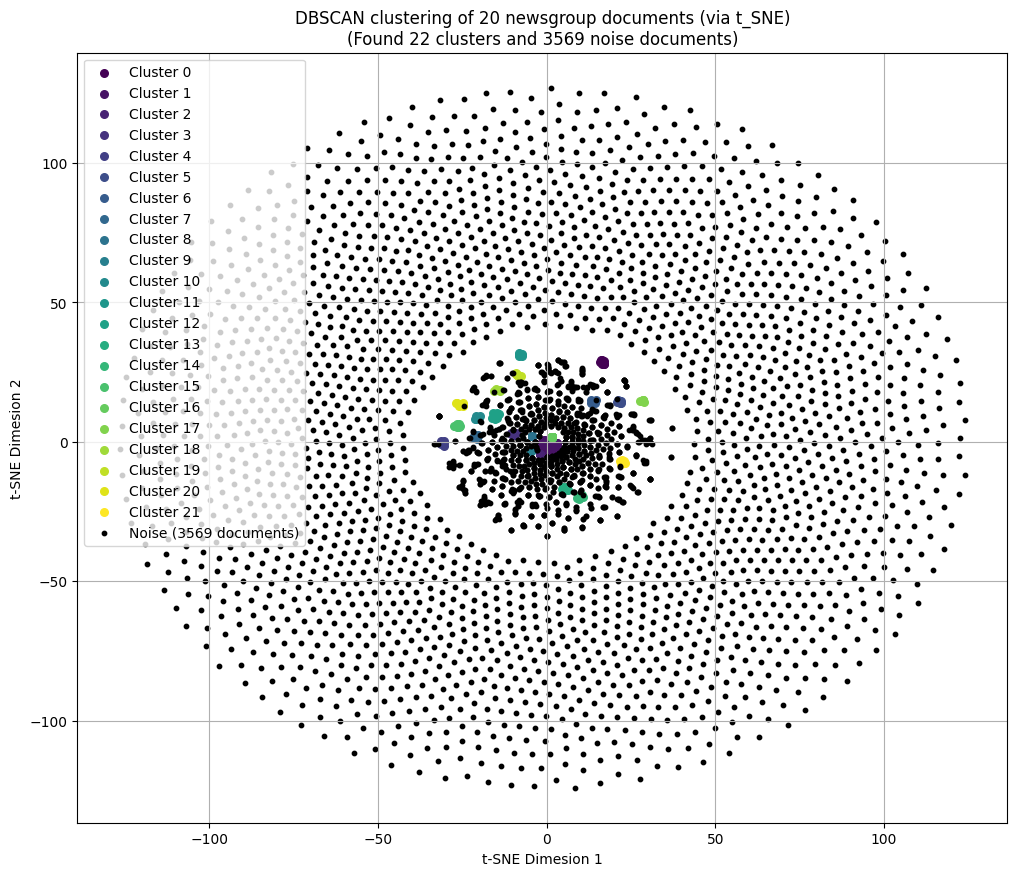

In [ ]:
#Step 6 : Visualization the Document Clusters
##Get the number of clusters and noise points found
unique_labels = set(cluster_labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(cluster_labels).count(-1)

plt.figure(figsize=(12, 10))

#Use a color palette for the clusters
colors = plt.cm.get_cmap('viridis', n_clusters)

#Plot each cluster (and noise) one by one
for label in unique_labels :
  class_mask = (cluster_labels == label)
  xy = X_tsne[class_mask]

  if label == -1:
    plt.scatter(xy[:,0], xy[:,1], s =10, c='k', label = f'Noise ({n_noise} documents)')
  else:
    plt.scatter(xy[:,0], xy[:,1], s =30, color = colors(label), label = f'Cluster {label}')

plt.title(f'DBSCAN clustering of 20 newsgroup documents (via t_SNE)\n(Found {n_clusters} clusters and {n_noise} noise documents)')
plt.xlabel('t-SNE Dimesion 1')
plt.ylabel('t-SNE Dimesion 2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Step 7 : Display the evaluation report
#Compare the discovered clusters to the true newsgroup categories
comparison_df = pd.DataFrame({
    'DBSCAN Cluster' : cluster_labels,
    'Actual Category' : [target_names[i] for i in y_test]
})

evaluation_table = pd.crosstab(comparison_df['DBSCAN Cluster'], comparison_df['Actual Category'])

print("--- Evaluation Report : Comparing Document Clusters to actual Newsgroup categories ---")
print("Note : The algorithm did NOT use the category labels during clustering")
print("The label '-1' represents documents that the algorithm idetified as noise/outliers")
print(evaluation_table)

--- Evaluation Report : Comparing Document Clusters to actual Newsgroup categories ---
Note : The algorithm did NOT use the category labels during clustering
The label '-1' represents documents that the algorithm idetified as noise/outliers
Actual Category  rec.sport.baseball  sci.crypt  sci.electronics  \
DBSCAN Cluster                                                    
-1                              866        908              937   
 0                                0          0                0   
 1                               37         20               20   
 2                                2          3                3   
 3                                8          0                0   
 4                                0         10                0   
 5                                0          0                0   
 6                                8          0                0   
 7                                0          0                0   
 8                    